In [1]:
# HW5/3 — Approximation of Trial Solutions for 1D Problems


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Exact displacement
def u_exact(x):
    return x**3

# Exact strain
def strain_exact(x):
    return 3*x**2

In [3]:
# Number of elements
n_elements = 2

# Create nodes
nodes = np.linspace(0, 1, n_elements + 1)

# Nodal displacements from exact solution
d = nodes**3

print("Nodes:")
print(nodes)

print("\nNodal displacements:")
print(d)

Nodes:
[0.  0.5 1. ]

Nodal displacements:
[0.    0.125 1.   ]


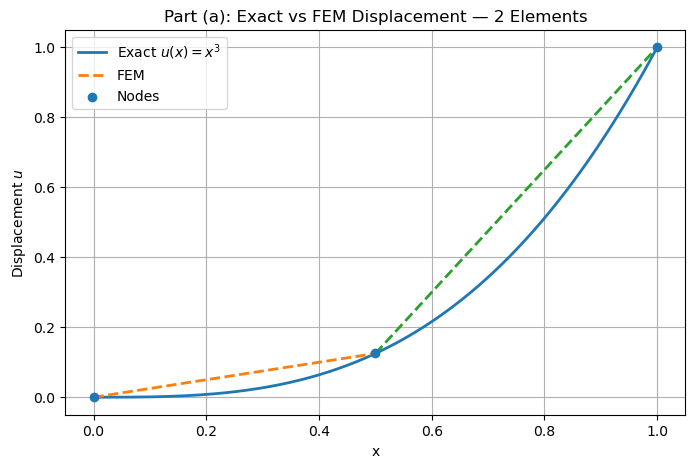

In [4]:
# Plot exact and finite element displacement

x_plot = np.linspace(0, 1, 500)

plt.figure(figsize=(8, 5))

# Exact solution
plt.plot(
    x_plot,
    u_exact(x_plot),
    label='Exact $u(x)=x^3$',
    linewidth=2
)

# FEM solution element-by-element
for e in range(n_elements):

    x1 = nodes[e]
    x2 = nodes[e+1]

    d1 = d[e]
    d2 = d[e+1]

    x_e = np.linspace(x1, x2, 100)

    # Linear shape functions
    N1 = (x2 - x_e) / (x2 - x1)
    N2 = (x_e - x1) / (x2 - x1)

    # FEM displacement
    u_e = N1*d1 + N2*d2

    plt.plot(
        x_e,
        u_e,
        '--',
        linewidth=2,
        label='FEM' if e == 0 else None
    )

# Plot nodes
plt.scatter(
    nodes,
    d,
    label='Nodes',
    zorder=3
)

plt.xlabel('x')
plt.ylabel('Displacement $u$')
plt.title('Part (a): Exact vs FEM Displacement — 2 Elements')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
#ptb

Element 1: strain = 0.2500
Element 2: strain = 1.7500


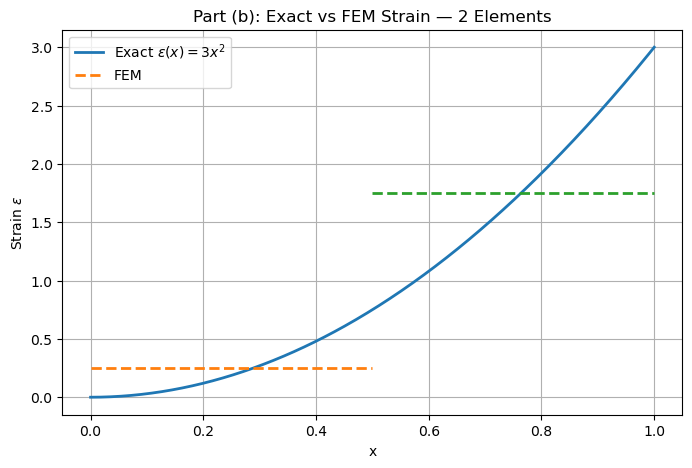

In [6]:
# Plot exact and FEM strain

plt.figure(figsize=(8, 5))

# Exact strain
plt.plot(
    x_plot,
    strain_exact(x_plot),
    label='Exact $\\epsilon(x)=3x^2$',
    linewidth=2
)

# FEM strain for each element
for e in range(n_elements):

    x1 = nodes[e]
    x2 = nodes[e+1]

    d1 = d[e]
    d2 = d[e+1]

    h = x2 - x1

    # B matrix
    B = np.array([-1/h, 1/h])

    # Element displacement vector
    d_e = np.array([d1, d2])

    # FEM strain
    epsilon_e = B @ d_e

    # Plot constant strain over element
    x_e = np.linspace(x1, x2, 100)

    plt.plot(
        x_e,
        np.full_like(x_e, epsilon_e),
        '--',
        linewidth=2,
        label='FEM' if e == 0 else None
    )

    print(f"Element {e+1}: strain = {epsilon_e:.4f}")

plt.xlabel('x')
plt.ylabel('Strain $\\epsilon$')
plt.title('Part (b): Exact vs FEM Strain — 2 Elements')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
#Ptc

In [9]:
def plot_fem_solution(n_elements):

    # Create nodes
    nodes = np.linspace(0, 1, n_elements + 1)

    # Exact nodal displacements
    d = nodes**3

    x_plot = np.linspace(0, 1, 500)

    # -------------------------
    # Displacement
    # -------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        x_plot,
        u_exact(x_plot),
        label='Exact $u(x)=x^3$',
        linewidth=2
    )

    for e in range(n_elements):

        x1 = nodes[e]
        x2 = nodes[e+1]

        d1 = d[e]
        d2 = d[e+1]

        x_e = np.linspace(x1, x2, 50)

        N1 = (x2 - x_e) / (x2 - x1)
        N2 = (x_e - x1) / (x2 - x1)

        u_e = N1*d1 + N2*d2

        plt.plot(
            x_e,
            u_e,
            '--',
            linewidth=2,
            label='FEM' if e == 0 else None
        )

    plt.scatter(
        nodes,
        d,
        zorder=3
    )

    plt.xlabel('x')
    plt.ylabel('Displacement $u$')
    plt.title(f'Part (c): Displacement — {n_elements} Elements')
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------------------------
    # Strain
    # -------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        x_plot,
        strain_exact(x_plot),
        label='Exact $\\epsilon(x)=3x^2$',
        linewidth=2
    )

    for e in range(n_elements):

        x1 = nodes[e]
        x2 = nodes[e+1]

        d1 = d[e]
        d2 = d[e+1]

        h = x2 - x1

        B = np.array([-1/h, 1/h])
        d_e = np.array([d1, d2])

        epsilon_e = B @ d_e

        x_e = np.linspace(x1, x2, 50)

        plt.plot(
            x_e,
            np.full_like(x_e, epsilon_e),
            '--',
            linewidth=2,
            label='FEM' if e == 0 else None
        )

    plt.xlabel('x')
    plt.ylabel('Strain $\\epsilon$')
    plt.title(f'Part (c): Strain — {n_elements} Elements')
    plt.legend()
    plt.grid(True)
    plt.show()

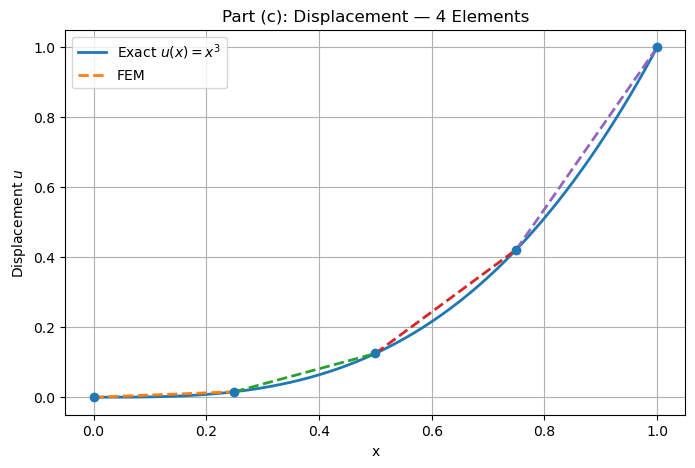

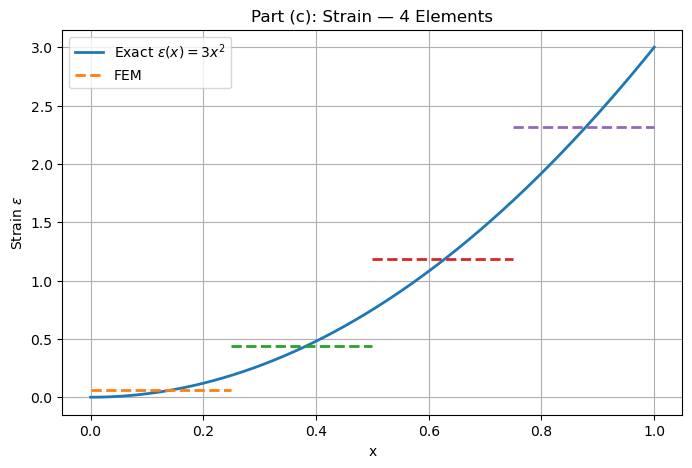

In [10]:
# 4 elements
plot_fem_solution(4)

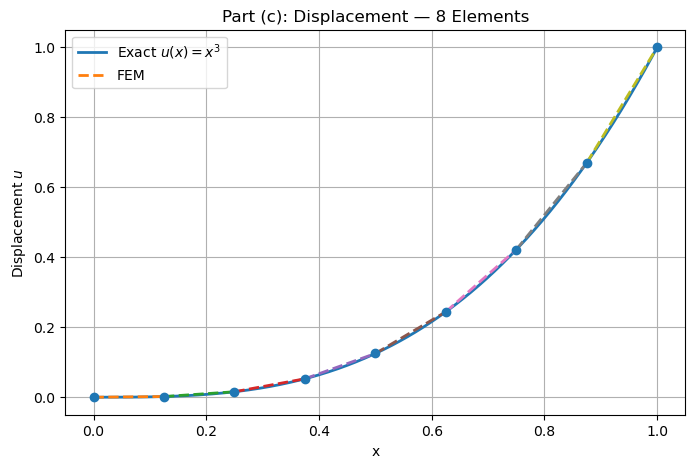

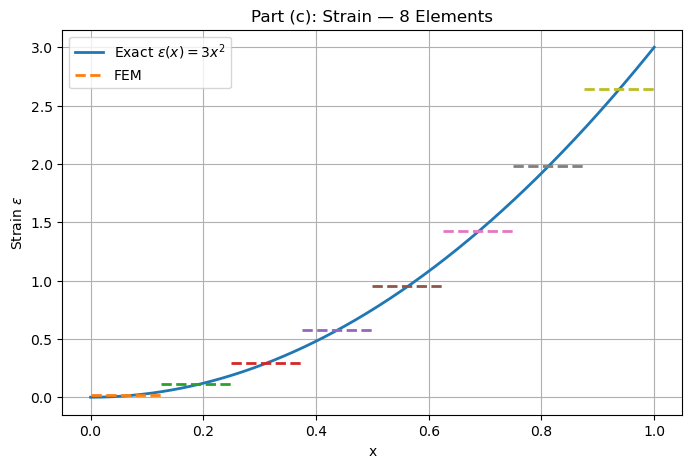

In [11]:
# 8 elements
plot_fem_solution(8)